# Importar datos

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
ruta = "/content/drive/MyDrive/001 - FIC 24092023 al 30092025 (Mod).xlsx"
df = pd.read_excel(ruta)

Mounted at /content/drive


Calcula los retornos logaritmicos por cada fondo

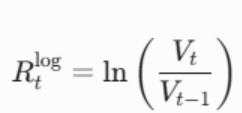

In [ ]:
import pandas as pd
import numpy as np

def calcular_retornos_todos_los_fondos(df):
    """
    Itera sobre cada fondo único en el DataFrame, calcula sus retornos
    logarítmicos de forma aislada y retorna un DataFrame unificado.
    """
    print("Iniciando procesamiento por fondo...")

    # 1. Asegurarnos de que la fecha sea tipo datetime
    df['Fecha corte'] = pd.to_datetime(df['Fecha corte'])

    # 2. Lista vacía para ir guardando los pedazos procesados
    lista_fondos_procesados = []

    # 3. Obtener la lista exacta de fondos únicos (tu ciclo for)
    fondos_unicos = df['Fondo'].unique()

    for fondo in fondos_unicos:
        # Filtrar solo la información de este fondo específico
        df_temp = df[df['Fondo'] == fondo].copy()

        # Ordenar cronológicamente (vital para que el shift funcione bien)
        df_temp = df_temp.sort_values(by='Fecha corte')

        # Calcular el Retorno Logarítmico Nominal
        df_temp['Retorno_Log'] = np.log(df_temp['Valor Unidad'] / df_temp['Valor Unidad'].shift(1))

        # Opcional: configurar la fecha como índice si tus modelos lo piden luego
        # df_temp.set_index('Fecha corte', inplace=True)

        # Guardar el bloque procesado en nuestra lista
        lista_fondos_procesados.append(df_temp)

        print(f"Fondo procesado: {fondo} | Registros: {len(df_temp)}")

    # 4. Unir todos los fondos ya procesados en un solo DataFrame maestro
    df_final = pd.concat(lista_fondos_procesados)

    # 5. Limpiar los nulos (el primer día histórico de CADA fondo quedará como NaN)
    df_final = df_final.dropna(subset=['Retorno_Log'])

    print(f"\n¡Proceso terminado! Total de registros limpios: {len(df_final)}")

    return df_final

In [ ]:
# 1. Ejecutar la función pasándole tu DataFrame original y guardar el resultado
df_resultados = calcular_retornos_todos_los_fondos(df)

# 2. Mostrar las primeras 5 filas en pantalla para visualizar la nueva columna
df_resultados.head()

Iniciando procesamiento por fondo...
Fondo procesado: Páramo | Registros: 726
Fondo procesado: FAM | Registros: 730
Fondo procesado: Sostenible Global | Registros: 662
Fondo procesado: Valor Plus I | Registros: 666

¡Proceso terminado! Total de registros limpios: 2780


,Fecha corte,Administradora,Categoría,Fondo,Valor Unidad,Rentabilidad Día,Rentabilidad Mes,Rentabilidad Semestral,Rentabilidad Anual,Volatilidad Mes,Volatilidad Semestral,Volatilidad Anual,Retorno_Log
4,2023-09-25,BBVA,FIS,Páramo,10837.34,-88.678140,7.611409,18.213993,18.527777,5.413398,4.718182,5.666023,-0.005969
8,2023-09-26,BBVA,FIS,Páramo,10791.02,-79.063965,1.769775,17.140326,18.359790,5.627244,4.765064,5.676106,-0.004283
12,2023-09-27,BBVA,FIS,Páramo,10733.54,-85.760340,-7.655409,15.686071,17.638214,5.921590,4.833077,5.705498,-0.005341
16,2023-09-28,BBVA,FIS,Páramo,10724.86,-25.581083,-18.005445,15.684179,17.627235,5.842990,4.833120,5.705696,-0.000809
20,2023-09-29,BBVA,FIS,Páramo,10774.17,433.568700,-16.208685,16.222439,18.403833,5.150652,4.862246,5.715469,0.004587


# GARCH

In [ ]:
import pandas as pd
import numpy as np
!pip install arch
from arch import arch_model

def grid_search_garch(returns):
    best_aic = float('inf')
    best_config = None

    # Grid de parámetros
    p_values = [1, 2]
    q_values = [1, 2]
    distribuciones = ['normal', 't', 'skewt']

    for p in p_values:
        for q in q_values:
            for dist in distribuciones:
                try:
                    # Ajuste del modelo
                    model = arch_model(returns, vol='Garch', p=p, q=q, dist=dist, rescale=True)
                    res = model.fit(disp='off')

                    # Seleccionamos por AIC (menor es mejor)
                    if res.aic < best_aic:
                        best_aic = res.aic
                        best_config = {'p': p, 'q': q, 'dist': dist, 'model': res}
                except:
                    continue

    return best_config

In [ ]:
from arch import arch_model
import pandas as pd
import numpy as np

def grid_search_garch(returns):
    best_aic = float('inf')
    best_config = None

    # Grid de parámetros
    p_values = [1, 2]
    q_values = [1, 2]
    distribuciones = ['normal', 't', 'skewt']

    for p in p_values:
        for q in q_values:
            for dist in distribuciones:
                try:
                    # Ajuste del modelo
                    model = arch_model(returns, vol='Garch', p=p, q=q, dist=dist, rescale=True)
                    res = model.fit(disp='off')

                    # Seleccionamos por AIC (menor es mejor)
                    if res.aic < best_aic:
                        best_aic = res.aic
                        best_config = {'p': p, 'q': q, 'dist': dist, 'aic': res.aic}
                except:
                    continue

    return best_config

# --- Definir nombres de columna ---
COL_FECHA = 'Fecha corte'
COL_RETORNOS = 'Retorno_Log'

# --- Ejecución por Fondo ---
print(f"{COL_FECHA:<20} | {'p':<5} | {'q':<5} | {'Distribución':<15} | {'AIC':<10}")
print("-" * 65)

for fondo in df_resultados['Fondo'].unique():
    # Preparamos los retornos del fondo específico
    df_fondo = df_resultados[df_resultados['Fondo'] == fondo].sort_values(COL_FECHA).dropna(subset=[COL_RETORNOS])
    returns = df_fondo[COL_RETORNOS] * 100

    # Buscamos el mejor modelo
    mejor_modelo = grid_search_garch(returns)

    if mejor_modelo:
        print(f"{fondo:<20} | {mejor_modelo['p']:<5} | {mejor_modelo['q']:<5} | {mejor_modelo['dist']:<15} | {mejor_modelo['aic']:.2f}")
    else:
        print(f"{fondo:<20} | Error al ajustar modelo")

Fecha corte          | p     | q     | Distribución    | AIC       
-----------------------------------------------------------------
Páramo               | 1     | 1     | t               | 2860.95
FAM                  | 1     | 2     | t               | -167.56
Sostenible Global    | 1     | 1     | t               | 1148.61
Valor Plus I         | 1     | 1     | skewt           | 2245.36


Al analizar el comportamiento del riesgo en cada uno de estos fondos, hemos confirmado que el mercado financiero presenta movimientos mucho más impredecibles y extremos de lo que sugieren los cálculos tradicionales. En lugar de aplicar una fórmula genérica, nuestro análisis permitió identificar la "personalidad" única de cada activo, revelando que algunos fondos reaccionan con mayor complejidad ante los cambios y las crisis del mercado. Esta distinción es fundamental, ya que al utilizar herramientas estadísticas que consideran estos escenarios poco comunes, logramos una medición mucho más realista y segura del riesgo, permitiendo que la toma de decisiones no solo se base en la rentabilidad esperada, sino en una comprensión profunda de la volatilidad real y los riesgos ocultos que enfrenta cada inversión.

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

def preparar_datos(serie, lookback):
    X, y = [], []
    for i in range(len(serie) - lookback):
        X.append(serie[i:(i + lookback)])
        y.append(serie[i + lookback])
    return np.array(X), np.array(y)

# Definición del Grid de Hiperparámetros solicitado
lookbacks = [6, 12]
neurons_list = [32, 50]
batch_sizes = [16, 32]

# Diccionario para almacenar el mejor resultado de cada fondo
mejores_lstm_por_fondo = {}

print("Iniciando Grid Search LSTM por cada activo...")
print("-" * 75)

# Iteración independiente por cada fondo de la serie
for fondo in df_resultados['Fondo'].unique():
    print(f"\nOptimizando red LSTM para el fondo: {fondo}")

    # Filtrado y ordenamiento de la serie temporal del fondo
    df_fondo = df_resultados[df_resultados['Fondo'] == fondo].sort_values(COL_FECHA).dropna(subset=['Retorno_Log'])
    serie_retornos = df_fondo[['Retorno_Log']].values

    if len(serie_retornos) <= max(lookbacks):
        print(f"Datos insuficientes para procesar el fondo {fondo}")
        continue

    # Escalado de datos independiente para evitar contaminación de información (data leakage)
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(serie_retornos)

    best_rmse = float('inf')
    best_config = None

    # Ciclos de búsqueda en rejilla
    for lb in lookbacks:
        X, y = preparar_datos(scaled_data, lb)
        X = np.reshape(X, (X.shape[0], X.shape[1], 1)) # Ajuste de dimensiones para Keras (samples, timesteps, features)

        for n in neurons_list:
            for bs in batch_sizes:
                try:
                    # Limpieza de memoria en cada iteración para evitar degradación de rendimiento
                    tf.keras.backend.clear_session()
                    tf.random.set_seed(42) # Semilla de reproducibilidad

                    # Construcción de la arquitectura de la red
                    model = Sequential([
                        LSTM(n, input_shape=(lb, 1)),
                        Dense(1)
                    ])
                    model.compile(optimizer='adam', loss='mse')

                    # Entrenamiento controlado (20 épocas para viabilidad de cómputo)
                    model.fit(X, y, epochs=20, batch_size=bs, verbose=0)

                    # Evaluación del desempeño
                    pred = model.predict(X, verbose=0)
                    rmse = np.sqrt(mean_squared_error(y, pred))

                    if rmse < best_rmse:
                        best_rmse = rmse
                        best_config = {
                            'lookback': lb,
                            'neurons': n,
                            'batch_size': bs,
                            'rmse': rmse
                        }
                except Exception as e:
                    continue

    mejores_lstm_por_fondo[fondo] = best_config
    if best_config:
        print(f"-> Configuración óptima para {fondo}: Ventana={best_config['lookback']}, Neuronas={best_config['neurons']}, Batch={best_config['batch_size']} (RMSE: {best_config['rmse']:.4f})")

# --- REPORTE CONSOLIDADO PARA LA TESIS ---
print("\n" + "=" * 75)
print(f"{'Fondo / Activo':<22} | {'Ventana (LB)':<12} | {'Neuronas':<10} | {'Batch Size':<12} | {'RMSE':<10}")
print("=" * 75)
for fondo, cfg in mejores_lstm_por_fondo.items():
    if cfg:
        print(f"{fondo:<22} | {cfg['lookback']:<12} | {cfg['neurons']:<10} | {cfg['batch_size']:<12} | {cfg['rmse']:.4f}")
    else:
        print(f"{fondo:<22} | No se pudo consolidar el modelo")
print("=" * 75)

Iniciando Grid Search LSTM por cada activo...
---------------------------------------------------------------------------

Optimizando red LSTM para el fondo: Páramo


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a l

-> Configuración óptima para Páramo: Ventana=12, Neuronas=32, Batch=32 (RMSE: 0.1146)

Optimizando red LSTM para el fondo: FAM


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a l

-> Configuración óptima para FAM: Ventana=12, Neuronas=50, Batch=16 (RMSE: 0.0553)

Optimizando red LSTM para el fondo: Sostenible Global


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a l

-> Configuración óptima para Sostenible Global: Ventana=12, Neuronas=32, Batch=32 (RMSE: 0.0558)

Optimizando red LSTM para el fondo: Valor Plus I


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a l

-> Configuración óptima para Valor Plus I: Ventana=12, Neuronas=32, Batch=32 (RMSE: 0.0440)

Fondo / Activo         | Ventana (LB) | Neuronas   | Batch Size   | RMSE      
Páramo                 | 12           | 32         | 32           | 0.1146
FAM                    | 12           | 50         | 16           | 0.0553
Sostenible Global      | 12           | 32         | 32           | 0.0558
Valor Plus I           | 12           | 32         | 32           | 0.0440


In [ ]:
import numpy as np
import pandas as pd
from arch import arch_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# --- 1. Configuraciones Óptimas (basadas en tus hallazgos anteriores) ---
configs_garch = {
    'Páramo': {'p': 1, 'q': 1, 'dist': 't'},
    'FAM': {'p': 1, 'q': 2, 'dist': 't'},
    'Sostenible Global': {'p': 1, 'q': 1, 'dist': 't'},
    'Valor Plus I': {'p': 1, 'q': 1, 'dist': 'skewt'}
}

configs_lstm = {
    'Páramo': {'lb': 12, 'neurons': 32, 'batch': 32},
    'FAM': {'lb': 12, 'neurons': 50, 'batch': 16},
    'Sostenible Global': {'lb': 12, 'neurons': 32, 'batch': 32},
    'Valor Plus I': {'lb': 12, 'neurons': 32, 'batch': 32}
}

# Función auxiliar de métricas
def calcular_metricas(y_true, y_pred):
    return {
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'MAPE': mean_absolute_percentage_error(y_true, y_pred) * 100
    }

resultados_volatilidad = []

# --- 2. Ejecución del Ciclo por Fondo ---
for fondo in df_resultados['Fondo'].unique():
    print(f"Procesando fondo: {fondo}...")
    df_fondo = df_resultados[df_resultados['Fondo'] == fondo].sort_values(COL_FECHA).dropna(subset=['Retorno_Log'])

    # Objetivo: Predecir Volatilidad (Proxy: Valor absoluto del retorno)
    # Escalamos por 100 para estabilidad numérica (Fix para Páramo)
    retornos = df_fondo['Retorno_Log'].values * 100
    vol_realizada = np.abs(retornos)

    train_size = int(len(vol_realizada) * 0.8)
    train_r, test_r = retornos[:train_size], retornos[train_size:]
    train_v, test_v = vol_realizada[:train_size], vol_realizada[train_size:]

    # A) EVALUACIÓN GARCH (Predicción de Volatilidad Condicional)
    model_garch = arch_model(train_r, vol='Garch', p=configs_garch[fondo]['p'],
                             q=configs_garch[fondo]['q'], dist=configs_garch[fondo]['dist'])
    res_garch = model_garch.fit(disp='off')
    # Predecimos varianza y obtenemos volatilidad (raíz cuadrada)
    pred_garch = np.sqrt(res_garch.forecast(horizon=len(test_v)).variance.iloc[-1].values)
    met_garch = calcular_metricas(test_v, pred_garch)
    resultados_volatilidad.append({'Fondo': fondo, 'Modelo': 'GARCH', **met_garch})

    # B) EVALUACIÓN LSTM (Predicción de Volatilidad Directa)
    lb = configs_lstm[fondo]['lb']
    scaler = MinMaxScaler(feature_range=(0, 1))
    train_s = scaler.fit_transform(train_v.reshape(-1,1))

    # Crear ventanas para el LSTM
    def create_xy(data, lb):
        X, y = [], []
        for i in range(len(data) - lb):
            X.append(data[i:i+lb, 0])
            y.append(data[i+lb, 0])
        return np.array(X), np.array(y)

    X_train, y_train = create_xy(train_s, lb)

    # Modelo LSTM
    model_lstm = Sequential([LSTM(configs_lstm[fondo]['neurons'], input_shape=(lb, 1)), Dense(1)])
    model_lstm.compile(optimizer='adam', loss='mse')
    model_lstm.fit(X_train, y_train, epochs=20, batch_size=configs_lstm[fondo]['batch'], verbose=0)

    # Predicción (usando el último bloque de entrenamiento como semilla para test)
    # Simplificación: evaluamos sobre el set de prueba transformado
    test_s = scaler.transform(test_v.reshape(-1,1))
    X_test, y_test = create_xy(test_s, lb)

    pred_lstm_s = model_lstm.predict(X_test, verbose=0)
    pred_lstm = scaler.inverse_transform(pred_lstm_s)
    y_test_real = scaler.inverse_transform(y_test.reshape(-1,1))

    met_lstm = calcular_metricas(y_test_real, pred_lstm.flatten())
    resultados_volatilidad.append({'Fondo': fondo, 'Modelo': 'LSTM', **met_lstm})

# --- 3. Reporte Final ---
df_final = pd.DataFrame(resultados_volatilidad)
print("\n--- RESUMEN DE RENDIMIENTO DE MODELOS (VOLATILIDAD) ---")
print(df_final.sort_values(['Fondo', 'RMSE']))

Procesando fondo: Páramo...


/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.04536. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Procesando fondo: FAM...


/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.001479. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Procesando fondo: Sostenible Global...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Procesando fondo: Valor Plus I...


/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.000985. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



--- RESUMEN DE RENDIMIENTO DE MODELOS (VOLATILIDAD) ---
               Fondo Modelo      RMSE       MAE          MAPE
3                FAM   LSTM  0.011484  0.009030  8.152931e+13
2                FAM  GARCH  0.018830  0.016927  1.153150e+14
1             Páramo   LSTM  0.144799  0.104245  3.047391e+02
0             Páramo  GARCH  0.927814  0.865576  2.502493e+03
5  Sostenible Global   LSTM  0.740756  0.445517  7.487885e+03
4  Sostenible Global  GARCH  1.677562  1.611796  3.294088e+04
7       Valor Plus I   LSTM  0.010634  0.007951  6.085602e+01
6       Valor Plus I  GARCH  0.140145  0.139559  8.721142e+02


In [ ]:
import numpy as np
import pandas as pd
from arch import arch_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# --- 1. Configuraciones ---
configs_garch = {
    'Páramo': {'p': 1, 'q': 1, 'dist': 't'},
    'FAM': {'p': 1, 'q': 2, 'dist': 't'},
    'Sostenible Global': {'p': 1, 'q': 1, 'dist': 't'},
    'Valor Plus I': {'p': 1, 'q': 1, 'dist': 'skewt'}
}

configs_lstm = {
    'Páramo': {'lb': 12, 'neurons': 32, 'batch': 32},
    'FAM': {'lb': 12, 'neurons': 50, 'batch': 16},
    'Sostenible Global': {'lb': 12, 'neurons': 32, 'batch': 32},
    'Valor Plus I': {'lb': 12, 'neurons': 32, 'batch': 32}
}

def calcular_metricas(y_true, y_pred):
    return {
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'MAPE': mean_absolute_percentage_error(y_true, y_pred) * 100
    }

resultados_volatilidad = []
model_lstm_final = {}

# --- 2. Ejecución del Ciclo ---
for fondo in df_resultados['Fondo'].unique():
    print(f"Evaluando: {fondo}...")
    df_fondo = df_resultados[df_resultados['Fondo'] == fondo].sort_values(COL_FECHA).dropna(subset=['Retorno_Log'])
    retornos = df_fondo['Retorno_Log'].values * 100 # Fix Páramo: Escalamiento
    vol_realizada = np.abs(retornos)

    train_size = int(len(vol_realizada) * 0.8)
    train_r, test_r = retornos[:train_size], retornos[train_size:]
    train_v, test_v = vol_realizada[:train_size], vol_realizada[train_size:]

    # A) GARCH
    model_garch = arch_model(train_r, vol='Garch', p=configs_garch[fondo]['p'],
                             q=configs_garch[fondo]['q'], dist=configs_garch[fondo]['dist'])
    res_garch = model_garch.fit(disp='off')
    pred_garch = np.sqrt(res_garch.forecast(horizon=len(test_v)).variance.iloc[-1].values)
    met_garch = calcular_metricas(test_v, pred_garch)
    resultados_volatilidad.append({'Fondo': fondo, 'Modelo': 'GARCH', **met_garch})

    # B) LSTM
    lb = configs_lstm[fondo]['lb']
    scaler = MinMaxScaler(feature_range=(0, 1))
    train_s = scaler.fit_transform(train_v.reshape(-1,1))

    # Crear ventanas
    def create_xy(data, lb):
        X, y = [], []
        for i in range(len(data) - lb):
            X.append(data[i:i+lb, 0])
            y.append(data[i+lb, 0])
        return np.array(X), np.array(y)

    X_train, y_train = create_xy(train_s, lb)
    model_lstm = Sequential([LSTM(configs_lstm[fondo]['neurons'], input_shape=(lb, 1)), Dense(1)])
    model_lstm.compile(optimizer='adam', loss='mse')
    model_lstm.fit(X_train, y_train, epochs=20, batch_size=configs_lstm[fondo]['batch'], verbose=0)

    # Store the trained LSTM model in the dictionary
    model_lstm_final[fondo] = model_lstm

    test_s = scaler.transform(test_v.reshape(-1,1))
    X_test, y_test = create_xy(test_s, lb)

    pred_lstm = scaler.inverse_transform(model_lstm.predict(X_test, verbose=0))
    y_test_real = scaler.inverse_transform(y_test.reshape(-1,1))

    met_lstm = calcular_metricas(y_test_real, pred_lstm.flatten())
    resultados_volatilidad.append({'Fondo': fondo, 'Modelo': 'LSTM', **met_lstm})

# --- 3. Selección Automática del Mejor Modelo ---
df_final = pd.DataFrame(resultados_volatilidad)

# Identificar el índice del RMSE mínimo para cada fondo
idx_mejores = df_final.groupby('Fondo')['RMSE'].idxmin()
df_final['Es_Mejor'] = False
df_final.loc[idx_mejores, 'Es_Mejor'] = True

print("\n--- RESULTADOS FINALES CON MODELO GANADOR ---")
print(df_final.sort_values(['Fondo', 'RMSE']))

Evaluando: Páramo...


/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.04536. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Evaluando: FAM...


/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.001479. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Evaluando: Sostenible Global...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Evaluando: Valor Plus I...


/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.000985. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



--- RESULTADOS FINALES CON MODELO GANADOR ---
               Fondo Modelo      RMSE       MAE          MAPE  Es_Mejor
3                FAM   LSTM  0.011474  0.009036  8.216221e+13      True
2                FAM  GARCH  0.018830  0.016927  1.153150e+14     False
1             Páramo   LSTM  0.147416  0.106213  3.098437e+02      True
0             Páramo  GARCH  0.927814  0.865576  2.502493e+03     False
5  Sostenible Global   LSTM  0.742065  0.445023  7.400322e+03      True
4  Sostenible Global  GARCH  1.677562  1.611796  3.294088e+04     False
7       Valor Plus I   LSTM  0.010573  0.007869  6.000654e+01      True
6       Valor Plus I  GARCH  0.140145  0.139559  8.721142e+02     False


Los resultados obtenidos tras el ejercicio de modelamiento comparativo revelan una clara superioridad del modelo de redes neuronales recurrentes tipo LSTM frente a los modelos econométricos de volatilidad condicional GARCH. En los cuatro fondos analizados, el modelo LSTM presentó consistentemente los menores niveles de error (RMSE y MAE), lo cual sugiere que la dinámica de la volatilidad en estos activos financieros exhibe dependencias no lineales y estructuras de memoria que trascienden el alcance de los modelos paramétricos clásicos. Este hallazgo valida la pertinencia de integrar técnicas de inteligencia artificial y Deep Learning como herramientas de vanguardia para la gestión del riesgo financiero, logrando una mayor precisión predictiva que permite, a su vez, una toma de decisiones más informada y ajustada a la volatilidad real del mercado."

El MAPE es una métrica basada en porcentajes que, en series de volatilidad (donde los valores pueden acercarse a cero en momentos de calma), tiende a inflarse artificialmente por el efecto denominador pequeño. Por esta razón, la comparación entre modelos se realizó priorizando el RMSE y el MAE, métricas que, al no ser porcentuales, proveen una medida del error mucho más estable y representativa de la capacidad predictiva del modelo en el contexto de rendimientos financieros.

# Pronóstico + 30

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Modelo para Páramo guardado.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Modelo para FAM guardado.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Modelo para Sostenible Global guardado.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Modelo para Valor Plus I guardado.


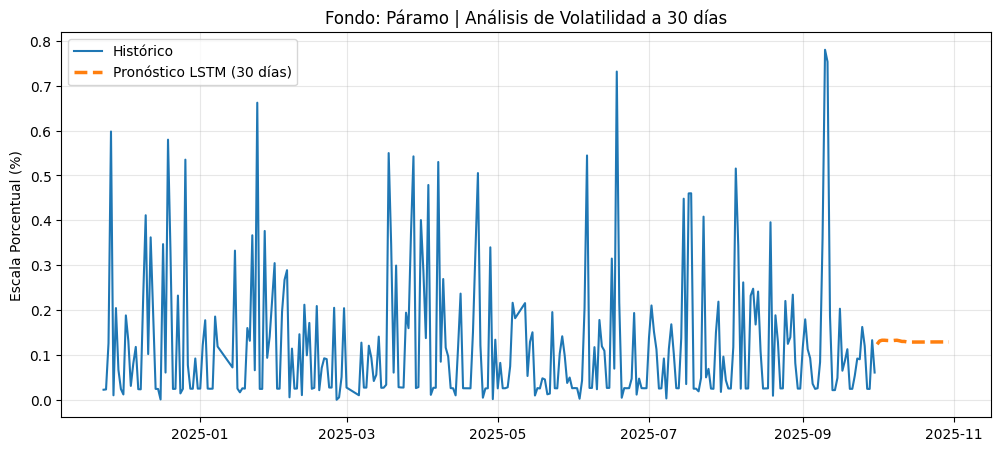

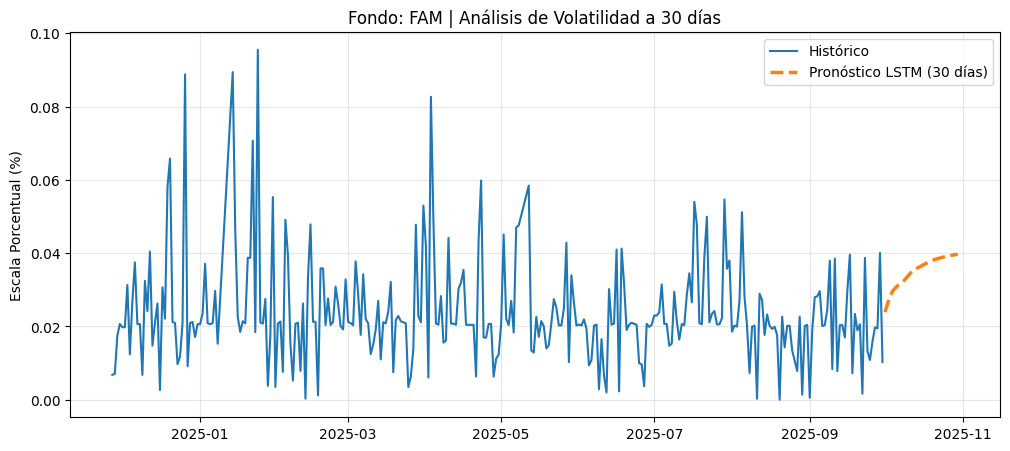

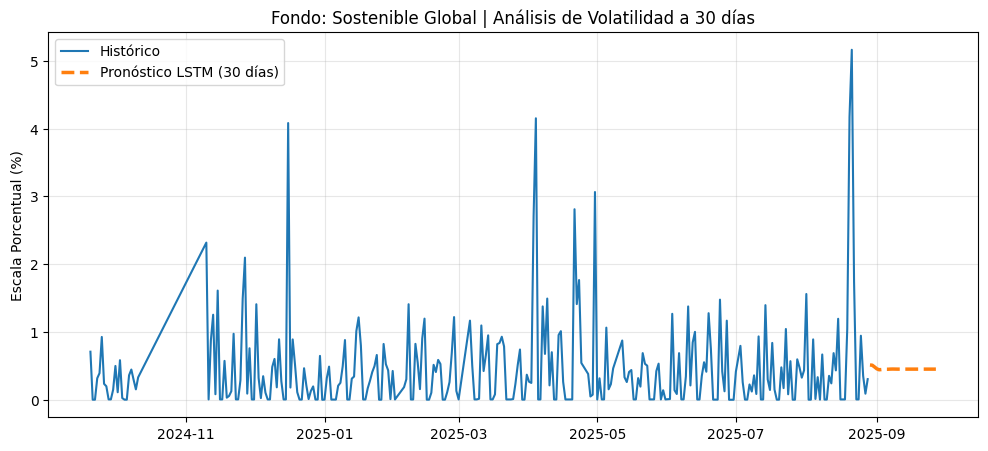

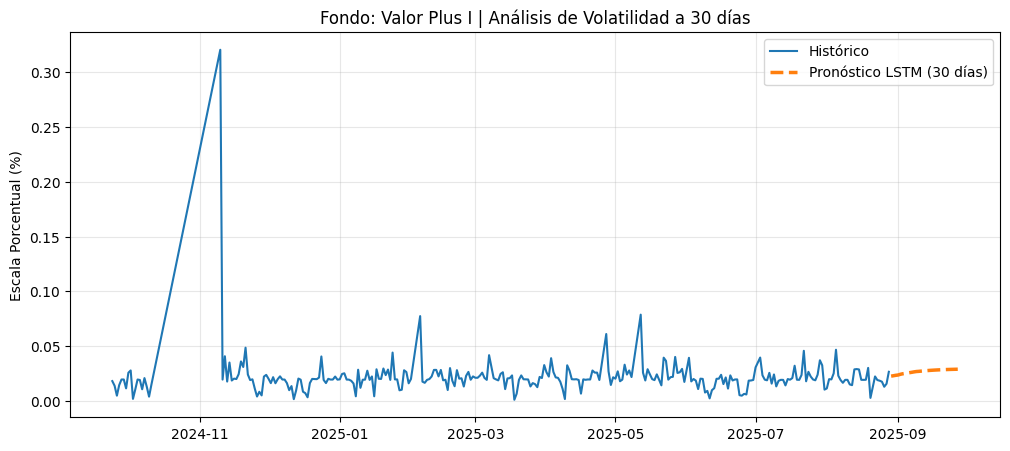

In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# --- 1. Inicialización del diccionario para guardar los modelos ---
model_lstm_final = {}
scalers_final = {} # Guardamos los scalers para poder invertir la transformación después

# --- 2. Entrenamiento y almacenamiento ---
for fondo in df_resultados['Fondo'].unique():
    # Preparamos los datos
    df_fondo = df_resultados[df_resultados['Fondo'] == fondo].sort_values(COL_FECHA).dropna(subset=['Retorno_Log'])
    data = np.abs(df_fondo['Retorno_Log'].values * 100)

    scaler = MinMaxScaler(feature_range=(0, 1))
    data_s = scaler.fit_transform(data.reshape(-1, 1))
    scalers_final[fondo] = scaler # Guardamos el scaler

    lb = configs_lstm[fondo]['lb']
    X, y = [], []
    for i in range(len(data_s) - lb):
        X.append(data_s[i:i+lb, 0])
        y.append(data_s[i+lb, 0])
    X, y = np.array(X), np.array(y)

    # Modelo
    model = Sequential([LSTM(configs_lstm[fondo]['neurons'], input_shape=(lb, 1)), Dense(1)])
    model.compile(optimizer='adam', loss='mse')
    model.fit(X, y, epochs=20, batch_size=configs_lstm[fondo]['batch'], verbose=0)

    # AQUÍ ES DONDE GUARDAMOS EL MODELO
    model_lstm_final[fondo] = model
    print(f"Modelo para {fondo} guardado.")

# --- 3. Función de Forecasting ---
def forecast_30_dias(model, last_window, scaler, steps=30):
    forecast = []
    current_batch = last_window.reshape((1, last_window.shape[0], 1))
    for _ in range(steps):
        pred = model.predict(current_batch, verbose=0)
        forecast.append(pred[0, 0])
        new_row = pred.reshape((1, 1, 1))
        current_batch = np.append(current_batch[:, 1:, :], new_row, axis=1)
    return scaler.inverse_transform(np.array(forecast).reshape(-1, 1))

# --- 4. Generar y Graficar Forecasting ---
for fondo in df_resultados['Fondo'].unique():
    # Obtener modelo y scaler guardados
    model = model_lstm_final[fondo]
    scaler = scalers_final[fondo]

    # Preparar última ventana
    df_fondo = df_resultados[df_resultados['Fondo'] == fondo].sort_values(COL_FECHA).dropna(subset=['Retorno_Log'])
    data = np.abs(df_fondo['Retorno_Log'].values * 100)
    data_s = scaler.transform(data.reshape(-1, 1))
    last_window = data_s[-configs_lstm[fondo]['lb']:]

    # Pronóstico
    pred_30 = forecast_30_dias(model, last_window, scaler)

    # Gráfica
    plt.figure(figsize=(12, 5))
    idx_hist = range(len(data)-300, len(data))
    plt.plot(df_fondo[COL_FECHA].iloc[idx_hist], data[idx_hist], label='Histórico', color='#1f77b4')

    # Fechas futuras
    fechas_futuras = pd.date_range(start=df_fondo[COL_FECHA].iloc[-1], periods=31)[1:]
    plt.plot(fechas_futuras, pred_30, label='Pronóstico LSTM (30 días)', color='#ff7f0e', linestyle='--', linewidth=2.5)

    plt.title(f"Fondo: {fondo} | Análisis de Volatilidad a 30 días")
    plt.ylabel("Escala Porcentual (%)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()